# Hydrological modeling

We will study catchment hydrology using the classic Nash reservoir model, a lumped model with a single compartment. We will combine mass conservation with the principal inflows and outflows to obtain a quantitative tool for predicting streamflow.

## Catchment water balance

The starting point for almost any hydrological model, and indeed most geophysical models, is an expression of the conservation of mass. We then have to select an appropriate control volume.

In hydrology, the concept of a catchment (also watershed, basin) provides a convenient control volume. We start by selecting a point along the stream network, called an outlet, which may be where a river enters the sea or a lake, but it may also be the location of a stream gauge. Loosely speaking, the catchment is then the set of all locations for which water at the surface would flow downhill toward our outlet. The catchment concept is based on the notion that water predominantly flows downstream at or very close to the surface, although there are exceptions to it, including blowing snow, groundwater flow, or in lowlying areas where the water depth is not small compared to the relief. If, however, water flows down the slope of the surface, then the only lateral flux will be in the stream at the outlet. The upper boundary of the catchment is usually taken to be the surface including the vegetation, while the lower surface is sufficiently deep for water flows across the boundary to become negligible at the timescales of interest.



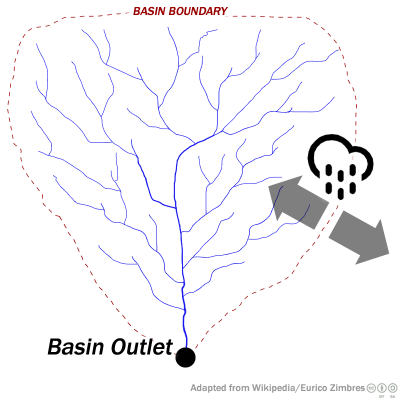

*An outlet's catchment, or drainage basin. From [weather.gov](https://weather.gov).*

The water balance for a catchment can then be modeled as
$$\frac{\mathrm{d}S}{\mathrm{d}t} = P - E - Q,$$
where $S$ is the total storage (snow, soil moisture, lakes, deep groundwater, etc.). $P$ is the (instantaneous) precipitation, $E$ the evaporation, and $Q$ streamflow at the outlet. While the quantity of interest is the water mass, we usually normalize by a reference density and work with volume, which is somewhat more intuitive.

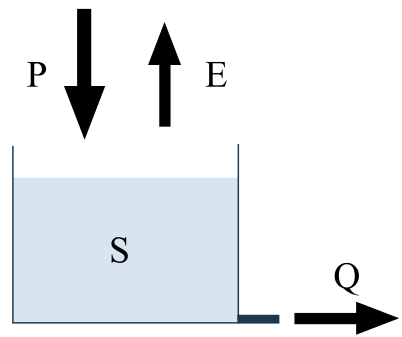

### Think about this at home



The catchment area of the Wulik river near Kivalina is 800 square miles, and its average annual streamflow approximately 5$\cdot$10$^8$ m$^3$. The average annual rainfall in Kivalina is 300 mm. Assuming the water storage to remain constant from year to year, what is the average evaporation per unit area across the catchment? List any additional assumptions you needed to make.

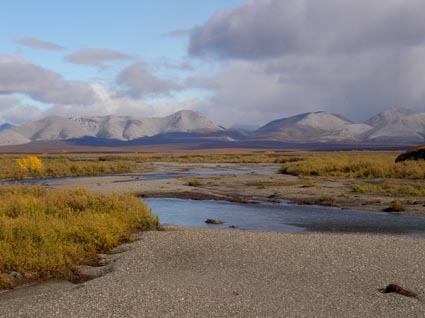

*The Wulik River during a low-flow period, from [alaska.net](http://www.alaska.net/~bakerb/nslope/wulik/wulik_04/wulik_04.htm).*

# Nash reservoir model

Nash's linear reservoir model predicts streamflow $Q$ based on the water balance for the catchment of interest. The idea is to model $Q(S)$ as a function of $S$. The precipitation $P$ and evaporation $E$ are prescribed, with $P$ usually being measured and $E$ modeled separately. There are many methods to model $E$ or, more directly, the effective rainfall $P_e \equiv P -  E$.

### Flow law
The streamflow $Q$ is expected to increase the more water is stored in the landscape. The Nash model's flow law is linear,
$$Q(S) = k S,$$
where $k$ is a parameter with dimension T$^{-1}$.



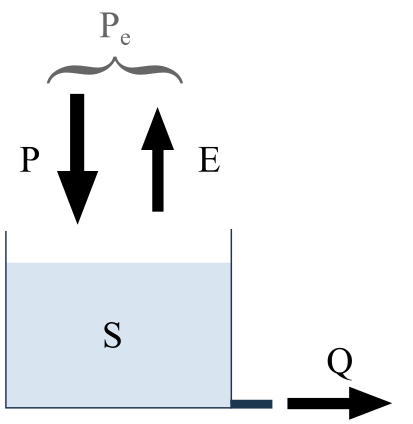

### Differential equation
The Nash reservoir model simplifies to an ordinary differential equation for the total storage. By plugging the flow law into the mass balance, we obtain
$$\frac{\mathrm{d}S}{\mathrm{d}t} + k S = P_e.$$







#### Steady state
To start exploring and understanding the model, we imagine a climate with negligible fluctuations (not even a diurnal cycle). Think of incessant drizzle with constant $P$. We will also assume that evaporation $E$ and thus effective precipitation $P_e$ are constant.

The Nash model permits a steady state solution. In other words, $S$ will be constant, implying $\frac{\mathrm{d}S}{\mathrm{d}t} = 0$. Thus,
$$kS = P_e.$$
The constant outflow $Q = kS$ exactly balances $P_e$. The storage is $S = P_e / k$. The greater $P_e$, the greater the storage. For fixed $P_e$, a leaky reservoir (large $k$; for instance, a karst landscape) will store less water.

### Winter recessions
Winter recessions are periods of decreasing flow during dry periods in winter, when $P_e$ is much smaller than $Q$. Setting $P_e = 0$, we obtain a homogeneous linear differential equation

$$\frac{\mathrm{d}S}{\mathrm{d}t} = -k S.$$

Its solution for an initial value of $S(t_0) = S_0$ at the beginning of the recession $t_0$, is

$$S(t) = S_0 \,\mathrm{exp}( -k (t-t_0)).$$
The storage decays exponentially with time.

So does the streamflow, as $Q(t) = k S(t)$, which we can rewrite as

$$Q(t) = Q_0 \,\mathrm{exp}( -k (t-t_0)),$$
with $Q_0 = Q(t_0)$.

The $e$-folding time scale of $Q$ and $S$ is $1/k$, which means that the storage and flow decrease by a factor of $\sim$2.7 over this time period. The e-folding time $1/k$ is also the turnover time.

Let's simulate a winter recession.

In [2]:
#@title Winter recession simulation
import matplotlib.pyplot as plt
import numpy as np

def plot_recession(k, Q0):
  t = np.arange(90) # [day]; evaluate streamflow every day
  Q_sim = Q0 * np.exp(-k * t) # t_0 = 0

  S_sim = Q_sim / k # storage in [m3]

  fig, axs = plt.subplots(nrows=2)
  axs[0].plot(t, Q_sim)
  axs[0].set_ylabel('Streamflow [m3/day]')
  axs[1].plot(t, S_sim)
  axs[1].set_xlabel('Time since start of recession [day]')
  _ = axs[1].set_ylabel('Storage [m3]')
  plt.show()

The following code cell plots the recession:

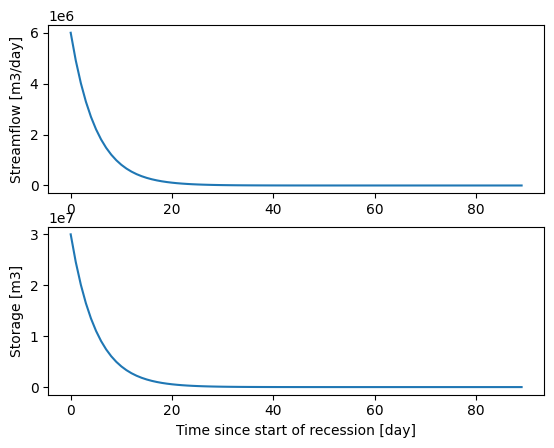

In [3]:
# Set the parameters (assumed known)
k = 0.2# [1/days]
Q0 = 6e6# [m3/day]

# Plot the recession curve
plot_recession(k, Q0)

## Case study: Wulik River recession

To predict the streamflow of the Wulik River for recession periods, we need to calibrate our model to observations. We will do so for a recession that happened at the end of the thaw period (rather than winter) in the wet summer of 2021.






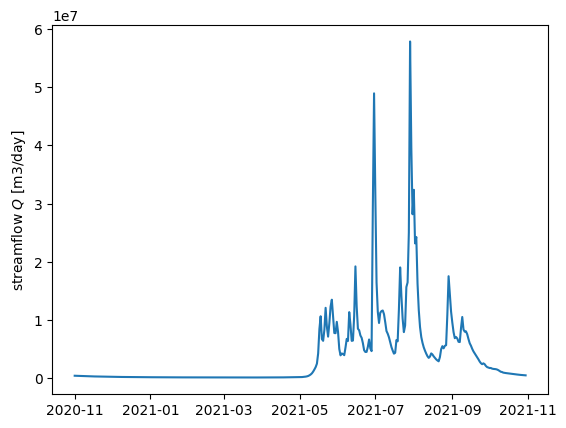

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DayLocator

%matplotlib inline

# Read the dataset from my github account
fnwulik = 'https://raw.githubusercontent.com/szwieback/ESS/main/wulik_2021.csv'
df = pd.read_csv(fnwulik)
df = df.set_index(pd.to_datetime(df['dt'])).drop(columns=['dt'])

# Plot the time series
fig, ax = plt.subplots()
ax.plot(df.index, df.Q)
_ = ax.set_ylabel('streamflow $Q$ [m3/day]')

We first note a few points of salience:


*   There is very little flow during winter in this permafrost-affected landscape (the streamflow estimates from this period are uncertain)
*   Streamflow during the snowmelt period in May is subdued compared to mid-summer peaks, which is unusual for Arctic rivers
*   Streamflow recessions after precipitation events show a gradual decline of streamflow

We will now focus on the recession period from September 09 to October 09.



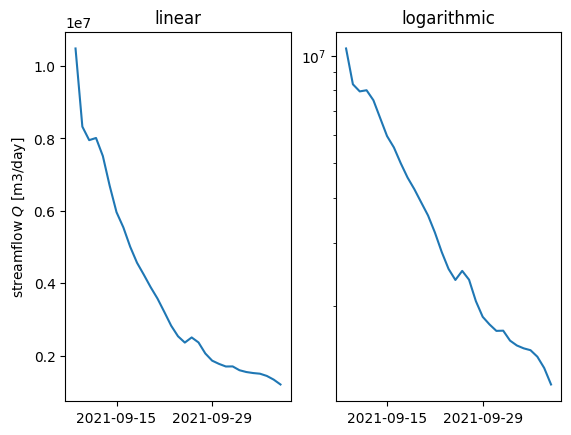

In [5]:
df_recession = df.loc['2021-09-09':'2021-10-09']

t = df_recession.index
t0 = df_recession.index[0]
Q_obs = df_recession.Q

# Plot recession (linear and logarithmic scale)
fig, axs = plt.subplots(ncols=2, sharex=True)
labels = ['linear', 'logarithmic']
for ax, lab in zip(axs, labels):
  ax.plot(t, Q_obs)
  ax.set_title(lab)
axs[1].set_yscale('log')
axs[0].xaxis.set_major_locator(DayLocator(interval=14))
_ = axs[0].set_ylabel('streamflow $Q$ [m3/day]')

The gradual decrease we see in the plot on the left mimics the recession we predicted using the Nash reservoir model.

The logarithmic plot on the right serves two purposes. First, it allows us to better resolve variations in streamflow for low discharges. Second, it facilitates assessment of whether the Nash model accurately predicts the streamflow. When we take the logarithm of the predicted $Q(t) = Q_0 \,\mathrm{exp}( -k (t-t_0))$, we obtain

$$\log Q(t) = \log Q_0 - k (t-t_0),$$
  
which is the equation of a line.

The observed recession can be approximated by a line reasonably well. We thus proceed further by calibrating the model to the observations.

In the following, you will need to manually adjust the parameters $Q_0$ and $k$ to improve the model fit.

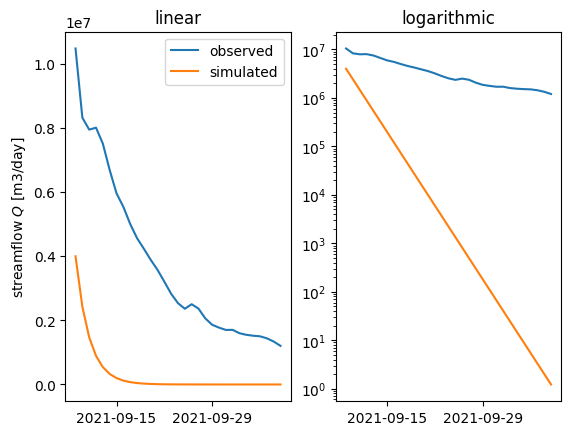

In [6]:
# change these values
k = 0.5# [1/days]
Q0 = 4e6# [m3/day]

# simulate Q
Q_sim = Q0 * np.exp(-k*(t - t0).days)

# Create the figure
fig, axs = plt.subplots(ncols=2, sharex=True)
labels = ['linear', 'logarithmic']
for ax, lab in zip(axs, labels):
  ax.plot(t, Q_obs, label='observed')
  ax.plot(t, Q_sim, label='simulated')
  ax.set_title(lab)
axs[0].legend()
axs[1].set_yscale('log')
axs[0].xaxis.set_major_locator(DayLocator(interval=14))
_ = axs[0].set_ylabel('streamflow $Q$ [m3/day]')

> 🧪 **Work in Pairs: Calibrating the model**
>
> **Instructions:** Manually adjust the parameters $Q_0$ and $k$. The goal is for the observed and simulated time series to match as closely as possible.
>
> **Questions:**
> 1. **Calibrated parameters:** What values of $k$ and $Q_0$ did you come up with?
> 2. **Interpretation:** Explain how to interpret $k$ in layman's terms. Hint: It may be easier to convert it to the turnover time.